# Building Groups

1. Create survey in Moodle
2. Download from Moodle (see Screenshot) data
3. Create HTML with the below script
4. Post HTML in the Group Building Block on Moodle

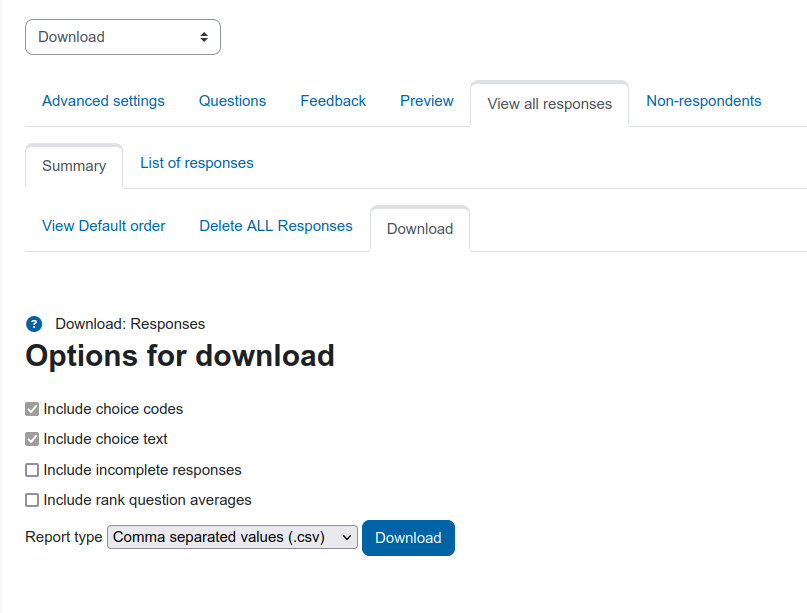

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.manifold import MDS

df = pd.read_csv("Group_Formation_Survey_Skills_Strengths_and_Interests.csv")

# print(len(df), "entries\n")
# print("Columns:\n")
# for col in df.columns:
# print(col)

# drop unnecessary columns

df = df.drop(
    ["Submitted on:", "Course", "Registration number", "Email address", "u:account"],
    axis=1,
)

# rename columns

replace_strings = [
    "Q00_",
    "Area of Interest in Psychology->",
    "Skills/Strengths->",
]
cols = list(df)

for i, _ in enumerate(cols):
    for replace_string in replace_strings:
        cols[i] = cols[i].replace(replace_string, "")

df = df.rename(columns=dict(zip(list(df), cols)))

rename_dict = {
    "Full name": "Name",
    "Clinical Psychology": "Clinical",
    "Cognitive Psychology": "CogPsy",
    "Developmental Psychology": "DevPsy",
    "Neuroscience": "Neuro",
    "Research Methods": "Methods",
    "Social Psychology": "SocialPsy",
    "Experimental Psychology": "ExpPsy",
    "Other Areas of Interest": "Other Interests",
    "Presentation": "Presenting",
    "Data Analysis": "Analyzing",
    "Creativity": "Creative",
    "Organizational skills": "Organizing",
    "Skills/Strengths": "Other Skills",
}

df = df.rename(columns=rename_dict)

# remove NaNs

df = df.fillna("")

# first names only

df["Name"] = df["Name"].str.split(expand=True).iloc[:, 1]

# keep only the last entry

df = df.drop_duplicates(subset=["Name"], keep="last")

# sort by name

df = df.sort_values("Name")

# Replace index

df = df.set_index("Name")
df.index.name = ""

# convert to html

styled_df = pd.DataFrame()


def df_to_html_with_checkboxes(df):
    "Convert DataFrame to HTML with checkboxes for boolean columns."

    def bool_to_checkbox(value):
        if value == 1:
            return '<div style="display: inline-flex; background-color: steelblue; width: auto; height: auto;"><input type="checkbox" checked disabled></div>'
        elif value == 0:
            return '<input type="checkbox" disabled>'
        else:
            return value

    # Apply bool_to_checkbox to each element in the DataFrame
    global styled_df
    styled_df = df.map(bool_to_checkbox)

    # Convert to HTML
    html = styled_df.to_html(escape=False)

    # Add CSS to center align all data and headers and style checkboxes
    html = html.replace(
        '<table border="1" class="dataframe">',
        '<table border="0" class="dataframe" style="width: 100%; text-align: center;">',
    )

    html = html.replace(
        "<td>",
        '<td style="min-width: 50px;">',
    )

    html = html.replace("<tr>", '<tr style="height: 40px;">')

    html = html.replace('<tr style="text-align: right;">', "<tr>")

    return html


# Convert your DataFrame and print HTML
html_table = df_to_html_with_checkboxes(df)
print(" ".join(html_table.split()))

## MDS for interests

In [ ]:
df_dis_i = 1 - (df[df.columns[:7]].T.corr() + 1) / 2

m = MDS(
    2,
    max_iter=1_000,
    normalized_stress=False,
    dissimilarity="precomputed",
    random_state=0,
)

m.fit(df_dis_i)

df[["interests_1", "interests_2"]] = m.embedding_

plt.figure(figsize=(6, 6))

for stud in df.index:
    noise_x, noise_y = np.random.uniform(-0.05, 0.05), np.random.uniform(-0.008, 0.008)
    plt.scatter(df.loc[stud, "interests_1"], df.loc[stud, "interests_2"])
    plt.text(
        df.loc[stud, "interests_1"] + noise_x,
        df.loc[stud, "interests_2"] + noise_y,
        stud,
    )

plt.title("MDS for interests")
plt.xlabel("mds 1")
plt.ylabel("mds 2")

## Reversed MDS for skills (skill matching)

In [ ]:
df_dis_s = (df[df.columns[8:15]].T.corr() + 1) / 2

m = MDS(
    2,
    max_iter=1_000,
    normalized_stress=False,
    dissimilarity="precomputed",
    random_state=0,
)

m.fit(df_dis_s)

df[["skills_1", "skills_2"]] = m.embedding_
df

plt.figure(figsize=(6, 6))

for stud in df.index:
    noise_x, noise_y = np.random.uniform(-0.05, 0.05), np.random.uniform(-0.008, 0.008)
    plt.scatter(df.loc[stud, "skills_1"], df.loc[stud, "skills_2"])
    plt.text(
        df.loc[stud, "skills_1"] + noise_x,
        df.loc[stud, "skills_2"] + noise_y,
        stud,
    )

plt.title("MDS for skills")
plt.xlabel("mds 1")
plt.ylabel("mds 2")

## Recommendation by combining both

In [ ]:
weight_interests = 0.5
weight_skills = 0.5

df_dis = weight_interests * df_dis_i + weight_skills * df_dis_s
np.fill_diagonal(df_dis.values, 1)

m = MDS(
    2,
    max_iter=1_000,
    normalized_stress=False,
    dissimilarity="precomputed",
    random_state=0,
)

m.fit(df_dis)

df[["profile_1", "profile_2"]] = m.embedding_
df

plt.figure(figsize=(6, 6))

for stud in df.index:
    noise_x, noise_y = np.random.uniform(-0.05, 0.05), np.random.uniform(-0.008, 0.008)
    plt.scatter(df.loc[stud, "profile_1"], df.loc[stud, "profile_2"])
    plt.text(
        df.loc[stud, "profile_1"] + noise_x,
        df.loc[stud, "profile_2"] + noise_y,
        stud,
    )

plt.title("MDS for combination of both")
plt.xlabel("mds 1")
plt.ylabel("mds 2")